🏆 Ujian Tengah Semester (UTS)

End-to-End Machine Learning: Fraud Detection

Import Library

In [40]:
!pip install wandb

In [51]:
import wandb

wandb.login()
wandb.init(project="nama-project")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE



Load Dataset

In [43]:
df = pd.read_csv('creditcard.csv')  # sesuaikan file kamu
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [44]:
print(df['Class'].isnull().sum())

0


In [45]:
df = df.dropna(subset=['Class'])

Exploratory Data Analysis (EDA)

Class
0    284315
1       492
Name: count, dtype: int64


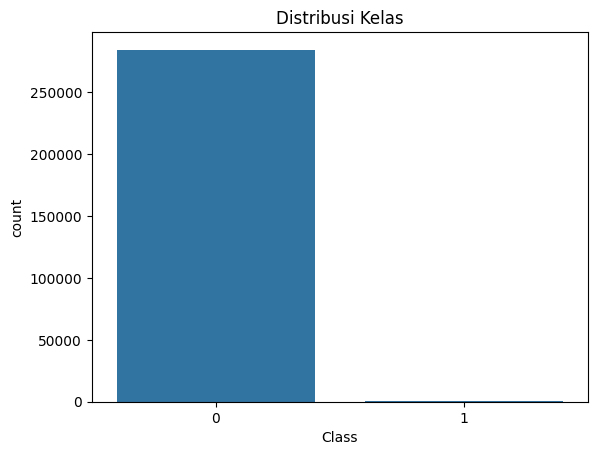

In [46]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Distribusi Kelas")
plt.show()

Data Splitting

In [47]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 👉 tambahan biar kelihatan hasilnya
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


Handling Imbalanced Data dengan SMOTE

In [48]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(pd.Series(y_train_res).value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


Model 1: Logistic Regression

In [49]:
wandb.init(project="credit-card-fraud-detection", name="Logistic Regression")

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_res, y_train_res)

y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print("\n--- LOGISTIC REGRESSION ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("AUPRC:", average_precision_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))


--- LOGISTIC REGRESSION ---
Accuracy: 0.9883957726203434
AUPRC: 0.7341787606905809
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model 2: Random Forest (Bagging)

In [36]:
wandb.init(project="credit-card-fraud-detection", name="Random Forest")

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n--- RANDOM FOREST ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUPRC:", average_precision_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


--- RANDOM FOREST ---
Accuracy: 0.999403110845827
AUPRC: 0.8740809794187884
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



Model 3: XGBoost (Boosting)

In [37]:
wandb.init(project="credit-card-fraud-detection", name="XGBoost")

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_res, y_train_res)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n--- XGBOOST ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUPRC:", average_precision_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))


--- XGBOOST ---
Accuracy: 0.9993504441557529
AUPRC: 0.8670802711132225
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



Confusion Matrix

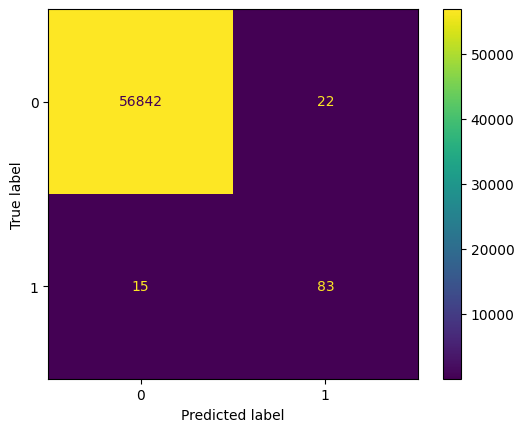

In [38]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Feature Importance

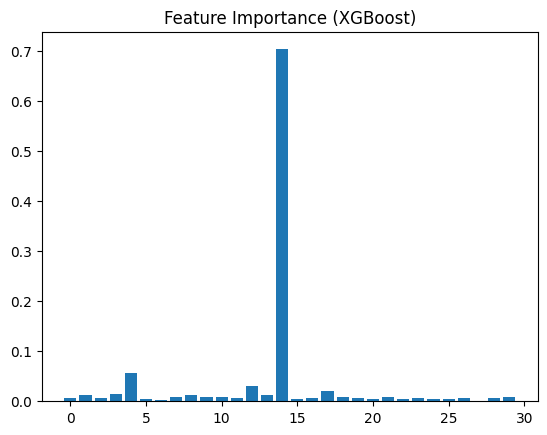

In [39]:
importances = xgb_model.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (XGBoost)")
plt.show()